In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time
import copy
import os
import pickle
from collections import Counter
from sklearn.metrics import log_loss

import import_ipynb
import importlib
import functions as fc
importlib.reload(fc)

print(os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\Exercise2


In [113]:
diabetes_train = pd.read_csv("datasets/diabetes_train.csv")
diabetes_test = pd.read_csv("datasets/diabetes_test.csv")

----------------------------------------------------------------------------------------------
-------------------------------------- ORIGINAL DATASET --------------------------------------
----------------------------------------------------------------------------------------------

In [114]:
X_train = diabetes_train.drop('Outcome', axis = 1)
X_test = diabetes_test.drop('Outcome', axis = 1)
y_train = diabetes_train['Outcome']
y_test = diabetes_test['Outcome']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Fit the model

In [115]:
#Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None
model = LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Prediction and utility

In [116]:
print("Training set: ")
fc.predict_binary(model, X_train_sc, y_train, conf_matrix=False)


Training set: 
---------------------------------------
Accuracy: 0.7801
Precision: 0.7241
Recall: 0.5915
F1 Score: 0.6512
---------------------------------------


---------------------------------------
Accuracy: 0.7662
Precision: 0.6863
Recall: 0.6364
F1 Score: 0.6604
---------------------------------------
          Predicted 0  Predicted 1
Actual 0           83           16
Actual 1           20           35


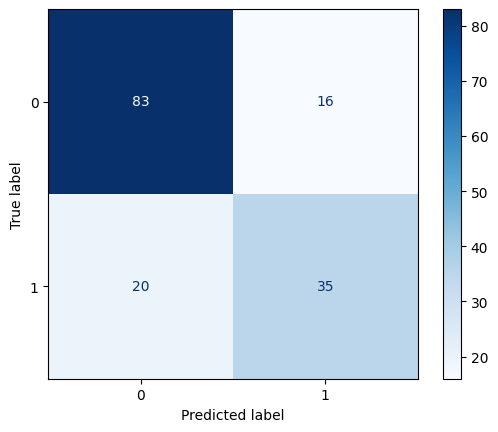

Saved results to results/model_results_diabetes.xlsx


In [117]:
fc.predict_binary_save_results(
    model,
    X_test_sc,
    y_test,
    conf_matrix = True,
    perturbation_type="Original",
    epsilon=0,
    output_file="results/model_results_diabetes.xlsx"
)


In [118]:
fc.cross_validate_model(model, X_train_sc, y_train, cv=10, bivariate = True)

Accuracy: 0.7671
Precision: 0.7101
Recall: 0.5675
F1 Score: 0.6284
Time: 0.20881915092468262


{'fit_time': array([0.0309515 , 0.00522399, 0.00630951, 0.0051434 , 0.00422144,
        0.00424147, 0.00542951, 0.00455451, 0.0045073 , 0.00622487]),
 'score_time': array([0.01253247, 0.01805568, 0.00937963, 0.00919199, 0.00899816,
        0.00852299, 0.0080049 , 0.00933003, 0.02651191, 0.01344872]),
 'test_accuracy': array([0.70967742, 0.75806452, 0.85483871, 0.77419355, 0.73770492,
        0.78688525, 0.78688525, 0.72131148, 0.78688525, 0.75409836]),
 'test_precision': array([0.57894737, 0.68421053, 0.88235294, 0.75      , 0.64705882,
        0.7       , 0.78571429, 0.6       , 0.78571429, 0.6875    ]),
 'test_recall': array([0.52380952, 0.59090909, 0.68181818, 0.54545455, 0.52380952,
        0.66666667, 0.52380952, 0.57142857, 0.52380952, 0.52380952]),
 'test_f1': array([0.55      , 0.63414634, 0.76923077, 0.63157895, 0.57894737,
        0.68292683, 0.62857143, 0.58536585, 0.62857143, 0.59459459])}

In [119]:
fc.hyperparameterTuning_save_Results(X_train_sc, y_train, cv=10, bivariate = True, perturbation_type="Original_hpt",
        epsilon=0, output_file="results/model_results_diabetes.xlsx")

Best parameters: {'C': 10}
Accuracy : 0.7687
Precision: 0.7121
Recall   : 0.5723
F1 Score : 0.6318
Time     : 0.19 s


(LogisticRegression(C=10, max_iter=1000), {'C': 10})

In [120]:
X_all = pd.concat([X_train, X_test], axis=0)
orig_confidence_scores = model.predict_proba(X_all)

with open("orig_confidence_scores_diabetes.pkl", "wb") as f:
    pickle.dump(orig_confidence_scores, f)

c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

### Perturb dataset

In [121]:
# Define ranges
ranges = [[0,20], [40,300], [30,200], [5,100], [2,900], [10,70], [0,3], [21,100]]
print(ranges)
sensitivity = []
for range in ranges:
    sensitivity.append(range[1]-range[0])
print(sensitivity)

[[0, 20], [40, 300], [30, 200], [5, 100], [2, 900], [10, 70], [0, 3], [21, 100]]
[20, 260, 170, 95, 898, 60, 3, 79]


In [122]:
epsilon_values = [0.01, 0.1, 1, 5, 10, 30, 50, 100]
perturbed_datasets = {}

np.random.seed(42)
for e in epsilon_values:
    X_train_perturbed = X_train.copy()
    d = X_train_perturbed.shape[1]

    for i, var in enumerate(X_train.columns):
        eps_j = e/d 
        scale = sensitivity[i] / eps_j   
        noise = np.random.laplace(loc=0,scale=scale,size=len(X_train))

        lower, upper = ranges[i]
        X_train_perturbed[var] = (
            X_train[var] + noise
        ).clip(lower=lower, upper=upper)

    perturbed_datasets[e] = X_train_perturbed

### Fit the model with the new datasets

In [123]:
input_confidence_scores = {}

for e in epsilon_values:
    input_model = copy.deepcopy(model)

    X_train_input = perturbed_datasets[e]
    scaler = StandardScaler()
    X_train_input_sc = scaler.fit_transform(X_train_input)
    X_test_input_sc = scaler.transform(X_test)

    input_model.fit(X_train_input_sc, y_train)

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(input_model, X_train_input_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        input_model,
        X_test_input_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Input",
        epsilon=e,
        output_file="results/model_results_diabetes.xlsx"
    )

    fc.hyperparameterTuning_save_Results(X_train_input_sc, y_train, cv=10, bivariate = True, perturbation_type="Input_hpt",
        epsilon=e, output_file="results/model_results_diabetes.xlsx")


    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train, X_test], axis=0)
    input_confidence_scores[e] = input_model.predict_proba(X_all)

with open("input_confidence_scores_diabetes.pkl", "wb") as f:
    pickle.dump(input_confidence_scores, f)


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Training set: 
---------------------------------------
Accuracy: 0.6531
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
---------------------------------------
Accuracy: 0.6429
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.6531
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
Time     : 0.18 s
Training set: 
---------------------------------------
Accuracy: 0.6547
Precision: 1.0000
Recall: 0.0047
F1 Score: 0.0093
---------------------------------------
---------------------------------------
Accuracy: 0.6429
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
Saved results to results/model_results_diabetes.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Best parameters: {'C': 0.01}
Accuracy : 0.6531
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
Time     : 0.16 s
Training set: 
---------------------------------------
Accuracy: 0.6531
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
---------------------------------------
Accuracy: 0.6429
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
Saved results to results/model_results_diabetes.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Best parameters: {'C': 0.01}
Accuracy : 0.6531
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
Time     : 0.17 s
Training set: 
---------------------------------------
Accuracy: 0.6547
Precision: 1.0000
Recall: 0.0047
F1 Score: 0.0093
---------------------------------------
---------------------------------------
Accuracy: 0.6429
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
Saved results to results/model_results_diabetes.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Best parameters: {'C': 0.01}
Accuracy : 0.6531
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
Time     : 0.16 s
Training set: 
---------------------------------------
Accuracy: 0.6547
Precision: 1.0000
Recall: 0.0047
F1 Score: 0.0093
---------------------------------------
---------------------------------------
Accuracy: 0.6429
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------
Saved results to results/model_results_diabetes.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Best parameters: {'C': 0.1}
Accuracy : 0.6548
Precision: 0.1000
Recall   : 0.0048
F1 Score : 0.0091
Time     : 0.15 s
Training set: 
---------------------------------------
Accuracy: 0.6694
Precision: 0.5568
Recall: 0.2300
F1 Score: 0.3256
---------------------------------------
---------------------------------------
Accuracy: 0.6623
Precision: 1.0000
Recall: 0.0545
F1 Score: 0.1034
---------------------------------------
Saved results to results/model_results_diabetes.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Best parameters: {'C': 0.01}
Accuracy : 0.6580
Precision: 0.5000
Recall   : 0.0708
F1 Score : 0.1179
Time     : 0.13 s
Training set: 
---------------------------------------
Accuracy: 0.7020
Precision: 0.6316
Recall: 0.3380
F1 Score: 0.4404
---------------------------------------
---------------------------------------
Accuracy: 0.6948
Precision: 0.7000
Recall: 0.2545
F1 Score: 0.3733
---------------------------------------
Saved results to results/model_results_diabetes.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Best parameters: {'C': 1}
Accuracy : 0.7036
Precision: 0.6347
Recall   : 0.3470
F1 Score : 0.4435
Time     : 0.15 s
Training set: 
---------------------------------------
Accuracy: 0.7182
Precision: 0.6370
Recall: 0.4366
F1 Score: 0.5181
---------------------------------------
---------------------------------------
Accuracy: 0.7727
Precision: 0.7273
Recall: 0.5818
F1 Score: 0.6465
---------------------------------------
Saved results to results/model_results_diabetes.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Best parameters: {'C': 0.1}
Accuracy : 0.7035
Precision: 0.6124
Recall   : 0.4082
F1 Score : 0.4848
Time     : 0.17 s


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [124]:
n = X_train.shape[0]
C_x = np.max(np.linalg.norm(X_train_sc, axis=1))
lambda_reg = 1 / model.C
sensitivity = (C_x*2) / (lambda_reg * n)

epsilon_values = [0.01, 0.1, 1, 5, 10, 30, 50, 100]
perturbed_coefficients = {}

np.random.seed(42)
for e in epsilon_values:
    coef_noise = np.random.laplace(loc=0,scale=sensitivity/e, size=model.coef_.shape)
    intercept_noise = np.random.laplace(loc=0,scale=sensitivity /e, size=model.intercept_.shape)
    perturbed_coefficients[e] = {
        "coef": model.coef_ + coef_noise,
        "intercept": model.intercept_ + intercept_noise
    }

In [125]:
output_confidence_scores = {}

for e in epsilon_values:
    output_model = copy.deepcopy(model)

    output_model.coef_ = perturbed_coefficients[e]["coef"]
    output_model.intercept_ = perturbed_coefficients[e]["intercept"]

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(output_model, X_train_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        output_model,
        X_test_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Output",
        epsilon=e,
        output_file="results/model_results_diabetes.xlsx"
    )

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train, X_test], axis=0)
    output_confidence_scores[e] = output_model.predict_proba(X_all)

with open("output_confidence_scores_diabetes.pkl", "wb") as f:
    pickle.dump(output_confidence_scores, f)

Training set: 
---------------------------------------
Accuracy: 0.6221
Precision: 0.4674
Recall: 0.6385
F1 Score: 0.5397
---------------------------------------
---------------------------------------
Accuracy: 0.5909
Precision: 0.4355
Recall: 0.4909
F1 Score: 0.4615
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.6694
Precision: 0.5298
Recall: 0.4178
F1 Score: 0.4672
---------------------------------------
---------------------------------------
Accuracy: 0.6688
Precision: 0.5400
Recall: 0.4909
F1 Score: 0.5143
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7752
Precision: 0.7219
Recall: 0.5728
F1 Score: 0.6387
---------------------------------------
---------------------------------------
Accuracy: 0.7662
Precision: 0.6939
Recall: 0.6182
F1 Score: 0.6538
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7769
Precision: 0.7184
Recall: 0.5869
F1 Score: 0.6460
---------------------------------------
---------------------------------------
Accuracy: 0.7597
Prec

c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7801
Precision: 0.7241
Recall: 0.5915
F1 Score: 0.6512
---------------------------------------
---------------------------------------
Accuracy: 0.7662
Precision: 0.6863
Recall: 0.6364
F1 Score: 0.6604
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7801
Precision: 0.7241
Recall: 0.5915
F1 Score: 0.6512
---------------------------------------
---------------------------------------
Accuracy: 0.7662
Precision: 0.6863
Recall: 0.6364
F1 Score: 0.6604
---------------------------------------
Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7801
Precision: 0.7241
Recall: 0.5915
F1 Score: 0.6512
---------------------------------------
---------------------------------------
Accuracy: 0.7662
Precision: 0.6863
Recall: 0.6364
F1 Score: 0.6604
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7801
Precision: 0.7241
Recall: 0.5915
F1 Score: 0.6512
---------------------------------------
---------------------------------------
Accuracy: 0.7662
Precision: 0.6863
Recall: 0.6364
F1 Score: 0.6604
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_diabetes.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------

In [126]:
data_norm = np.max(np.linalg.norm(X_train_sc, axis=1))
print("data_norm :", data_norm) #(max L2 norm of a scaled training row)

data_norm : 8.602929272067815


In [127]:
epsilon_values = [0.01, 0.1, 1, 5, 10, 30, 50, 100]

internal_models = fc.internal_perturbation_save_results(
    "diabetes",
    X_train_sc,
    y_train,
    X_test_sc,
    y_test,
    epsilon_values=epsilon_values,
    data_norm=data_norm,
    C=model.C,
    bivariate=True,
    output_file="results/model_results_diabetes.xlsx",
    perturbation_type="Internal"
)


---------------------------------------
Epsilon: 0.01
Accuracy: 0.5000
Precision: 0.3721
Recall: 0.5818
F1 Score: 0.4539
Time: 0.01 s
---------------------------------------
---------------------------------------
Epsilon: 0.1
Accuracy: 0.5195
Precision: 0.3855
Recall: 0.5818
F1 Score: 0.4638
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 1
Accuracy: 0.6169
Precision: 0.4722
Recall: 0.6182
F1 Score: 0.5354
Time: 0.01 s
---------------------------------------
---------------------------------------
Epsilon: 5
Accuracy: 0.7403
Precision: 0.6271
Recall: 0.6727
F1 Score: 0.6491
Time: 0.01 s
---------------------------------------
---------------------------------------
Epsilon: 10
Accuracy: 0.7532
Precision: 0.6604
Recall: 0.6364
F1 Score: 0.6481
Time: 0.01 s
---------------------------------------
---------------------------------------
Epsilon: 30
Accuracy: 0.7532
Precision: 0.6604
Recall: 0.6364
F1 Score: 0.6481
Time: 0.01 s
-------